# Detección de fraude 

El siguiente desarrollo presenta el entrenamiento de tres modelos basado en un dataset para la detección de fraude en transacciones de dinero. El objetivo es maximizar la ganancia de la empresa, teniendo en cuenta que  por cada transacción el porcentaje de ganancia es de un 25%, y por cada fraude aprobado se pierde el 100% del dinero de la transacción.

## Ejecución

Para ejecutar este código, ejecute las celdas en el orden presentado o mismo ejecute "run_all"

In [1]:
!pip install pandas numpy matplotlib scikit-learn lightgbm xgboost


[notice] A new release of pip is available: 26.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## EDA

A continuación se realiza un EDA que se basa en el análisis del dataset para entender qué parámetros se tienen, los valores de estos mismos y su relevancia en la clasificación. 

Este análisis va a permitir entender qué métodos de preprocesamiento se deben llevar a cabo antes de entrenar los modelos. 


In [3]:
df = pd.read_csv("MercadoLibre Data Scientist Technical Challenge - Dataset.csv")
df.head()

,a,b,c,d,e,f,g,h,j,k,l,m,n,o,p,fecha,monto,score,fraude
0,4,0.6812,50084.12,50.0,0.000000,20.0,AR,1,cat_d26ab52,0.365475,2479.0,952.0,1,NaN,Y,2020-03-20 09:28:19,57.63,100,0
1,4,0.6694,66005.49,0.0,0.000000,2.0,AR,1,cat_ea962fb,0.612728,2603.0,105.0,1,Y,Y,2020-03-09 13:58:28,40.19,25,0
2,4,0.4718,7059.05,4.0,0.463488,92.0,BR,25,cat_4c2544e,0.651835,2153.0,249.0,1,Y,Y,2020-04-08 12:25:55,5.77,23,0
3,4,0.7260,10043.10,24.0,0.046845,43.0,BR,43,cat_1b59ee3,0.692728,4845.0,141.0,1,N,Y,2020-03-14 11:46:13,40.89,23,0
4,4,0.7758,16584.42,2.0,0.154616,54.0,BR,0,cat_9bacaa5,0.201354,2856.0,18.0,1,Y,N,2020-03-23 14:17:13,18.98,71,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 19 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   a       150000 non-null  int64  
 1   b       137016 non-null  float64
 2   c       137016 non-null  float64
 3   d       149635 non-null  float64
 4   e       150000 non-null  float64
 5   f       149989 non-null  float64
 6   g       149806 non-null  object 
 7   h       150000 non-null  int64  
 8   j       150000 non-null  object 
 9   k       150000 non-null  float64
 10  l       149989 non-null  float64
 11  m       149635 non-null  float64
 12  n       150000 non-null  int64  
 13  o       41143 non-null   object 
 14  p       150000 non-null  object 
 15  fecha   150000 non-null  object 
 16  monto   150000 non-null  float64
 17  score   150000 non-null  int64  
 18  fraude  150000 non-null  int64  
dtypes: float64(9), int64(5), object(5)
memory usage: 21.7+ MB


In [5]:
df.columns

Index(['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'j', 'k', 'l', 'm', 'n', 'o',
       'p', 'fecha', 'monto', 'score', 'fraude'],
      dtype='object')

Podemos ver que existe una columna denominada "fraude", la cual indica si esa transacción fue clasificada como fraude o no. También, se tiene una columna de "score". Vamos a analizar esas dos columnas. 

In [6]:
print(
    'A continuación se puede observar el porcetaje de transacciones clasificadas como "fraude" y "legítimas":'
)

df["fraude"].value_counts(normalize=True) * 100


A continuación se puede observar el porcetaje de transacciones clasificadas como "fraude" y "legítimas":


fraude
0    95.0
1     5.0
Name: proportion, dtype: float64

Se puede concluir debido al porcentaje de transacciones legítimas y fraudulentas, que el dataset se encuentra desbalanceado. Hay un porcetaje menor de la clase de fraude que de legítimas.

Text(0.5, 0, 'Fraude')

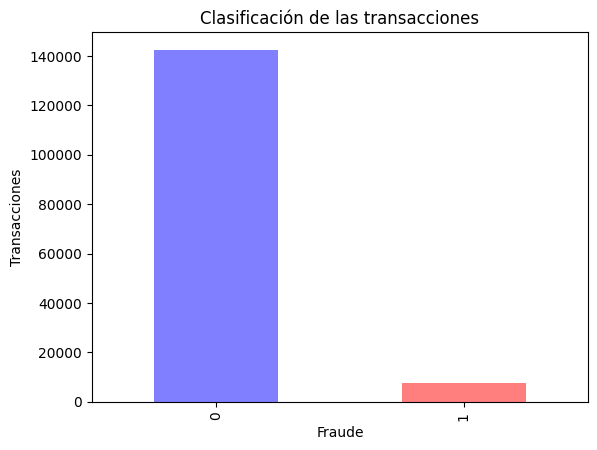

In [7]:
df["fraude"].value_counts().plot(
    kind="bar",
    title="Clasificación de las transacciones",
    color=["blue", "red"],
    alpha=0.5,
)
plt.ylabel("Transacciones")
plt.xlabel("Fraude")

In [8]:
print("Lista de valores de score: ", df["score"].unique())
print("Máximo de score: ", {df["score"].max()})
print("Mínimo de score: ", {df["score"].min()})


Lista de valores de score:  [100  25  23  71  30  20   0  52   8  65  77  70   1  36  50  86  12   7
  78  41  53  72  91  33  82  94  59  46  97  39  19  57  80  88  10  16
  61  63  13   4  69  79  48  73  35  76  21  14  42  22  96  74  89  51
  92  38  58  37  15  49  93   6  28  87   3  64  43  45  55  31  44  75
  85  54  56  60  62  99  84  27  95  26   2  66  34  68   5  17  18  29
  24   9  67  32  83  11  90  81  98  47  40]
Máximo de score:  {100}
Mínimo de score:  {0}


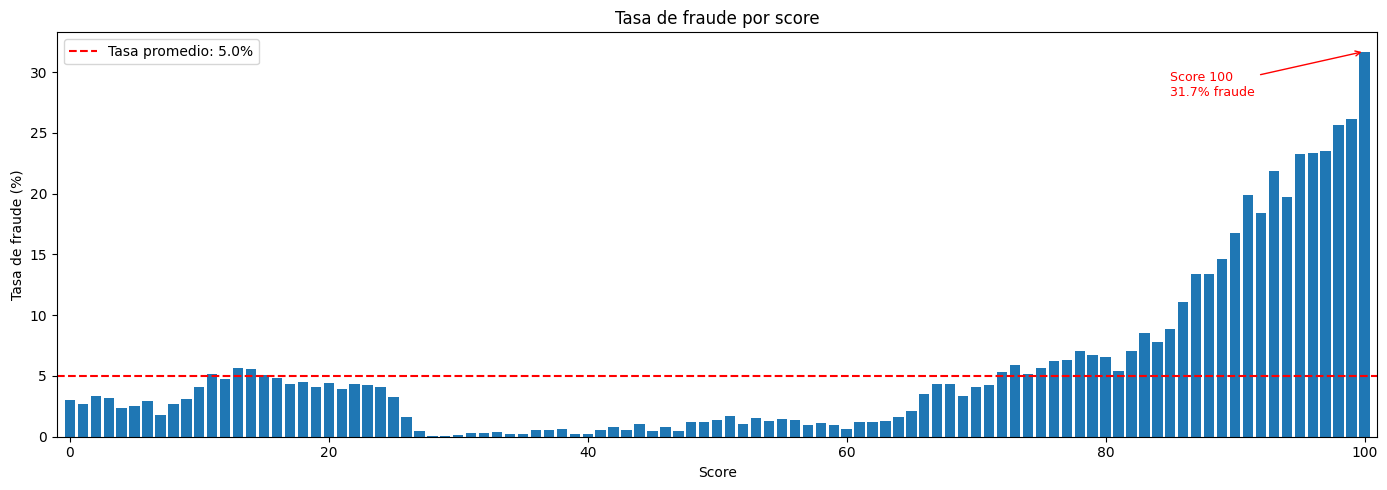

In [9]:
score_rate = df.groupby("score")["fraude"].agg(["mean", "count"]).reset_index()
score_rate.columns = ["score", "score_rate", "amount"]
score_rate["score_rate_porcentual"] = score_rate["score_rate"] * 100


fig, ax = plt.subplots(figsize=(14, 5))

ax.bar(score_rate["score"], score_rate["score_rate_porcentual"])

average_rate = df["fraude"].mean() * 100
ax.axhline(
    average_rate,
    color="red",
    linestyle="--",
    label=f"Tasa promedio: {average_rate:.1f}%",
)

ax.annotate(
    "Score 100\n31.7% fraude",
    xy=(100, 31.7),
    xytext=(85, 28),
    arrowprops=dict(arrowstyle="->", color="red"),
    fontsize=9,
    color="red",
)

ax.set_xlabel("Score")
ax.set_ylabel("Tasa de fraude (%)")
ax.set_title("Tasa de fraude por score")
ax.set_xlim(-1, 101)
ax.legend()

plt.tight_layout()
plt.show()

Con estos resultados se puede concluir:
- El dataset está desbalanceado debido a que el porcentaje de transacciones "legítimas" es del 95%, mientras que solamente tenemos un 5% de las muestras clasificadas como "fraude"
- El score no presenta una relación lineal con las transacciones clasificadas como "fraude". 

### Variables con valores nulos

Veamos qué otros tipos de variables hay y si contienen valores nulos 

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 19 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   a       150000 non-null  int64  
 1   b       137016 non-null  float64
 2   c       137016 non-null  float64
 3   d       149635 non-null  float64
 4   e       150000 non-null  float64
 5   f       149989 non-null  float64
 6   g       149806 non-null  object 
 7   h       150000 non-null  int64  
 8   j       150000 non-null  object 
 9   k       150000 non-null  float64
 10  l       149989 non-null  float64
 11  m       149635 non-null  float64
 12  n       150000 non-null  int64  
 13  o       41143 non-null   object 
 14  p       150000 non-null  object 
 15  fecha   150000 non-null  object 
 16  monto   150000 non-null  float64
 17  score   150000 non-null  int64  
 18  fraude  150000 non-null  int64  
dtypes: float64(9), int64(5), object(5)
memory usage: 21.7+ MB


En el dataset tenemos distintos tipos de variables, algunas refieren a números mientras que otras refieren a categorías (por ejemplo la columna 'g' se estima que refiere al país donde se hizo la transacción).

In [11]:
print(
    f"Veamos cuáles columnas tienen datos nulos en porcentaje: \n {df.isnull().sum() / df.shape[0] * 100}\n"
)


Veamos cuáles columnas tienen datos nulos en porcentaje: 
 a          0.000000
b          8.656000
c          8.656000
d          0.243333
e          0.000000
f          0.007333
g          0.129333
h          0.000000
j          0.000000
k          0.000000
l          0.007333
m          0.243333
n          0.000000
o         72.571333
p          0.000000
fecha      0.000000
monto      0.000000
score      0.000000
fraude     0.000000
dtype: float64



Se puede observar que tanto la columna "b", "c", "d", "f", "g", "l" y "o" contienen valores nulos en distintas proporciones. 
La solución a esta falta de datos en ciertas transacciones va a ser manejada distinta según el tipo de dato:
- Para aquellos valores numéricos, se va a realizar una imputación de la mediana o media. Esto se va a determinar según los outliers y la distribución simétrica
- Para aquellos valores categóricos, se va a remplazar los valores null por un strin "Sin_dato"

### Parámetros numéricos

Se consideran valores númericos a las columnas 'b', 'c', 'd', 'm', 'f', 'l'. 


De los valores numéricos, realizamos sus respectivos diagramas de 'Box plot' para analizar outliers y ver si hacemos imputación de la mediana o de la media

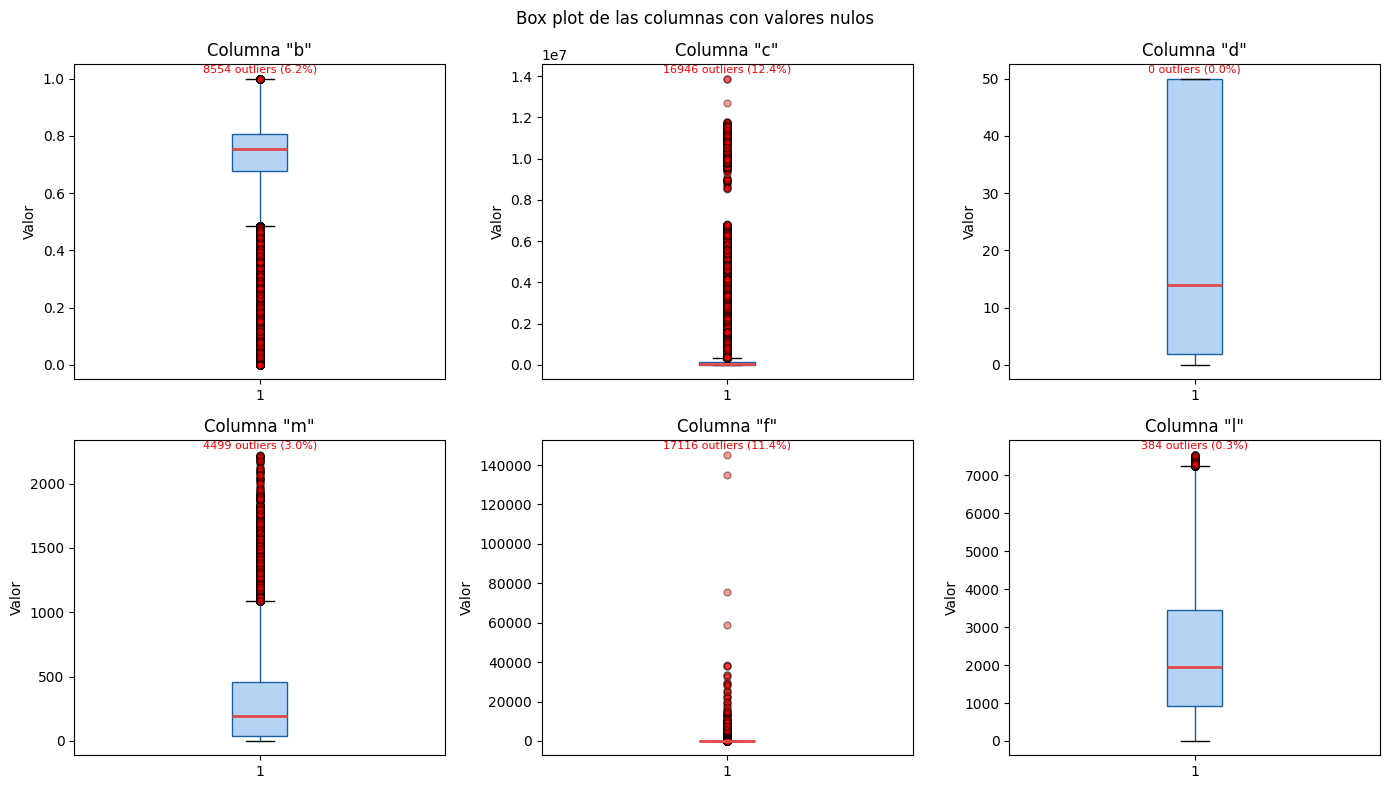

  Col      Media    Mediana   Outliers    Sesgo
    b       0.73       0.76          0     -1.63
    c  260445.11   43711.65      60011      6.72
    d      21.68      14.00          0      0.42
    m     299.97     193.00          0      1.38
    f      51.17       8.00        134    126.18
    l    2305.41    1937.00        384      0.68


In [12]:
cols = ["b", "c", "d", "m", "f", "l"]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(cols):
    data = df[col].dropna()

    mean = data.mean()
    median = data.median()
    q1 = data.quantile(0.25)
    q3 = data.quantile(0.75)
    iqr = q3 - q1
    upper_limit = q3 + 1.5 * iqr
    lower_limit = q1 - 1.5 * iqr
    n_outliers = (data > upper_limit).sum() + (data < lower_limit).sum()

    axes[i].boxplot(
        data,
        vert=True,
        patch_artist=True,
        boxprops=dict(facecolor="#b5d4f4", color="#185fa5"),
        medianprops=dict(color="#e34948", linewidth=2),
        whiskerprops=dict(color="#185fa5"),
        flierprops=dict(marker="o", markerfacecolor="red", markersize=5, alpha=0.4),
    )

    axes[i].set_title(f'Columna "{col}"')
    axes[i].set_ylabel("Valor")

    axes[i].text(
        0.5,
        1,
        f"{n_outliers} outliers ({n_outliers / len(data) * 100:.1f}%)",
        transform=axes[i].transAxes,
        fontsize=8,
        color="red",
        ha="center",
        va="top",
    )

fig.suptitle("Box plot de las columnas con valores nulos")
plt.tight_layout()
plt.show()

print(f"{'Col':>5} {'Media':>10} {'Mediana':>10} {'Outliers':>10} {'Sesgo':>8}")
for col in cols:
    data = df[col].dropna()
    q1 = data.quantile(0.25)
    q3 = data.quantile(0.75)
    upper_limit = q3 + 1.5 * iqr
    lower_limit = q1 - 1.5 * iqr
    out = ((data > upper_limit) | (data < lower_limit)).sum()
    sesgo = data.skew()
    print(
        f"{col:>5} {data.mean():>10.2f} {data.median():>10.2f} {out:>10}  {sesgo:>8.2f}"
    )

Por los resultados presentados en estos gráficos, la mayoría presenta outliers. Debido a esto, se decidió hacer una imputación por la mediana 

Además, a aquellas columnas con mayor porcentaje de valores nulos ("c", "b" y "o" ) vamos a agregar nuevas columnas que indiquen si el valor es nulo o no 

In [13]:
df["b_missing"] = df["b"].isnull().astype(int)
df["c_missing"] = df["c"].isnull().astype(int)
df["o_missing"] = df["o"].isnull().astype(int)


### Parámetros categóricos


Se consideran valores categóricos a las columnas  'g', 'o', 'j' y 'p'


 

Existen ciertas columnas, algunas ya mencionadas, que presentan valores categóricos.
Para el entrenamiento de los modelos, se necesitan números representativos de estas clases. 
Debido a que son clases que no tienen continuidad ni orden, su información se va a convertir en formaros de números binarios (una columna por cada categoría). Este preprocesamiento se determina como **One-Hot Encoding**

Esto se realiza una vez dividido el dataset en train y test para no generar leakage. 

Sin embargo, si hay alguna variable con muchas categorías esto puede generar que el dataset crezca demasiado.

Esto mismo sucede con la columna 'j', la cual como se ve a continuación presenta 8324 valores distintos. 
Por lo tanto, a esta columna, su información va a ser plasmada con una columna que indique la frecuencia de ocurrencia (**Frecuency Encoding**) de esa categoría.

Esto también va a ser realizado una vez que se divida el dataset entre train y test


In [14]:
len(df["j"].unique())

8324

### Fechas

Una de las columnas involucra las fechas de las transacciones. Debemos analizar estas fechas y sacar parámetros que permitan clasificar de mejor manera que las fechas como se presentan. 

Por lo tanto, se determinó agregar las siguientes columnas que permiten obtener datos de la fecha que son clasificables:
- Hora: consideramos 24 horas
- Día de la semana: lunes a domingo 
- Flag de fin de semana: analiza si es fin de semana o no
- Madrugada: analiza si fue realizada a la madrugada. Este parámetro fue agregado debido a que se tiene una intuición de que los fraudes se hacen en horarios donde los usuarios se encuentran mayoritariamente  dormidos.
- Tiempo desde la última transacción

In [15]:
df["fecha"] = pd.to_datetime(df["fecha"])
df["hora"] = df["fecha"].dt.hour
df["dia_semana"] = df["fecha"].dt.dayofweek
df["es_fin_de_semana"] = (df["fecha"].dt.dayofweek >= 5).astype(int)
df["es_madrugada"] = (df["fecha"].dt.hour.between(0, 5)).astype(int)
df["tiempo_desde_ult_tx"] = df["fecha"].diff().dt.total_seconds() / 60
df["tiempo_desde_ult_tx"] = df["tiempo_desde_ult_tx"].fillna(999999)


El dataset termina quedando como:

In [16]:
df.head()

,a,b,c,d,e,f,g,h,j,k,...,score,fraude,b_missing,c_missing,o_missing,hora,dia_semana,es_fin_de_semana,es_madrugada,tiempo_desde_ult_tx
0,4,0.6812,50084.12,50.0,0.000000,20.0,AR,1,cat_d26ab52,0.365475,...,100,0,0,0,1,9,4,0,0,999999.00
1,4,0.6694,66005.49,0.0,0.000000,2.0,AR,1,cat_ea962fb,0.612728,...,25,0,0,0,0,13,0,0,0,-15569.85
2,4,0.4718,7059.05,4.0,0.463488,92.0,BR,25,cat_4c2544e,0.651835,...,23,0,0,0,0,12,2,0,0,43107.45
3,4,0.7260,10043.10,24.0,0.046845,43.0,BR,43,cat_1b59ee3,0.692728,...,23,0,0,0,0,11,5,1,0,-36039.70
4,4,0.7758,16584.42,2.0,0.154616,54.0,BR,0,cat_9bacaa5,0.201354,...,71,0,0,0,0,14,0,0,0,13111.00


### Monto

Una de las variables más notorias es el monto. Uno creería que el monto de los fraudes es mayor. Vamos a realizar un análisis de los datos obtenidos

In [17]:
df["monto"].describe()

count    150000.000000
mean         43.523134
std          91.557888
min           0.020000
25%           9.380000
50%          20.610000
75%          40.692500
max        3696.350000
Name: monto, dtype: float64

In [18]:
df.groupby("fraude")["monto"].describe()

,count,mean,std,min,25%,50%,75%,max
fraude,,,,,,,,
0,142500.0,41.973326,85.708924,0.02,9.30,20.18,40.0225,3696.35
1,7500.0,72.969483,164.843328,0.21,10.82,25.87,59.0575,3424.81


Se puede observar que en promedio, los fraudes suelen ser de montos más altos. 


Text(0, 0.5, 'Cantidad de transacciones')

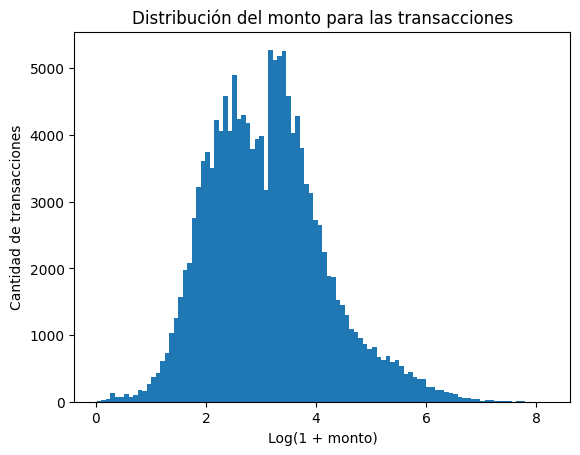

In [19]:
plt.hist(np.log1p(df["monto"]), bins=100)
plt.title("Distribución del monto para las transacciones")
plt.xlabel("Log(1 + monto)")
plt.ylabel("Cantidad de transacciones")

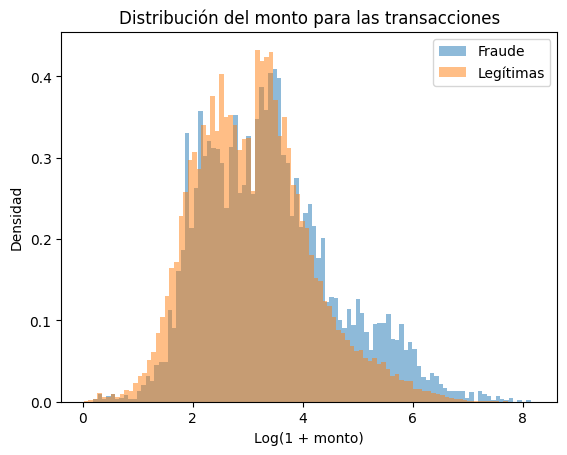

In [20]:
plt.hist(
    np.log1p(df[df["fraude"] == 1]["monto"]),
    bins=100,
    label="Fraude",
    density=True,
    alpha=0.5,
)
plt.hist(
    np.log1p(df[df["fraude"] == 0]["monto"]),
    bins=100,
    label="Legítimas",
    density=True,
    alpha=0.5,
)

plt.title("Distribución del monto para las transacciones")
plt.ylabel("Densidad")
plt.xlabel("Log(1 + monto)")
plt.legend()
plt.show()
plt.show()

Las conclusiones que se pueden obtener son:
1.  Los fraudes tienden a tener montos más altos. A partir de aproximadamente log(1+monto) > 4.5, la densidad de fraude (azul) empieza a quedar sistemáticamente por encima de la de no fraude. Por lo tanto, a mayor monto, aumenta la probabilidad relativa de que la transacción sea un fraude.

2. Las distribuciones se superponen mucho: el monto por sí solo no parece ser un predictor fuerte de fraude.



### País

Otro parámetro que se puede identificar es el de la fila "g"  y estimamos que indica el país. 

In [21]:
df["g"].unique()


array(['AR', 'BR', 'US', 'UY', nan, 'MX', 'SE', 'CO', 'IT', 'ES', 'RU',
       'GB', 'DO', 'PE', 'IN', 'CH', 'PT', 'CA', 'BE', 'PY', 'NZ', 'CR',
       'CL', 'DE', 'PR', 'FR', 'TR', 'EG', 'ZA', 'LB', 'PA', 'GE', 'CN',
       'AE', 'KR', 'EC', 'AU', 'NL', 'BS', 'UA', 'FI', 'AD', 'TW', 'NO',
       'HN', 'BO', 'GR', 'IL', 'GH', 'JP', 'PH', 'NI'], dtype=object)

In [22]:
print(len(df["g"].unique()))

52


<function matplotlib.pyplot.show(close=None, block=None)>

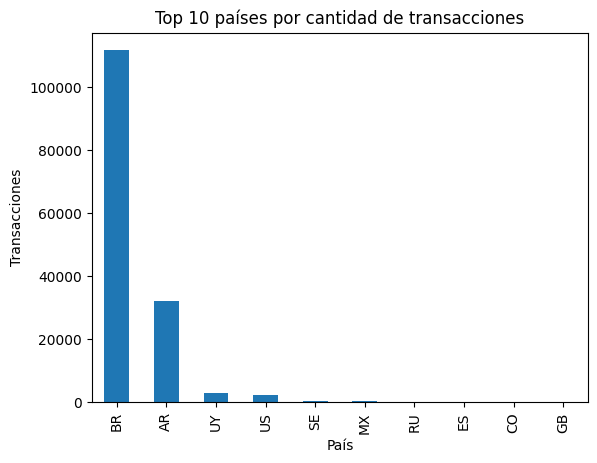

In [23]:
df["g"].value_counts().head(10).plot(
    kind="bar", title="Top 10 países por cantidad de transacciones"
)
plt.xlabel("País")
plt.ylabel("Transacciones")
plt.show

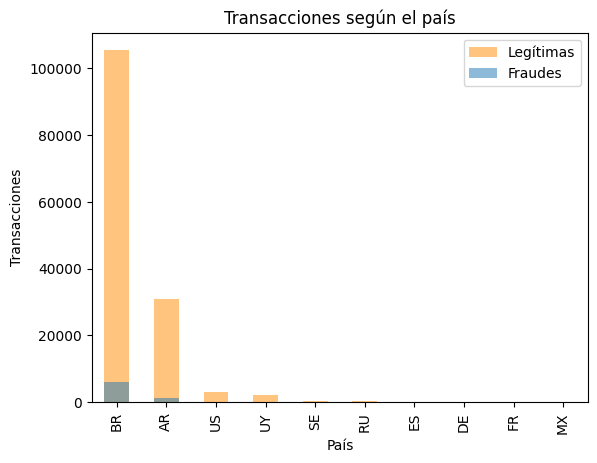

In [24]:
df[df["fraude"] == 0]["g"].value_counts().head(10).plot(
    kind="bar",
    title="Transacciones según el país",
    alpha=0.5,
    color="darkorange",
    label="Legítimas",
)

df[df["fraude"] == 1]["g"].value_counts().head(10).plot(
    kind="bar", alpha=0.5, label="Fraudes"
)
plt.legend()
plt.xlabel("País")
plt.ylabel("Transacciones")
plt.show()


Se puede concluir que en ciertos países suele generarse más fraues, aunque también en esos países son los que se generan más transacciones en general.

## Modelos

Recordemos el objetivo: maximizar la ganancia de la empresa entrenando un modelo de clasificación para detección de fraude. 

Vamos a realizar un entrenamiento de 3 modelos para analizar en las condiciones dadas cuál es mejor:

- RandomForest
- XGBClassifier
- LightGBM 

Las métricas de comparación van a ser:
- Ganancia de la empresa
- AUC-POC
- F1-Score
- Recall
- AUC-PR

La priortaria va a ser la ganancia 

### Separación del dataset y definición del pipeline

A continuación vamos a separar el dataset en test y train según las fechas y con un 20% para test y un 80% para train

Hay que considerar que el dataset está desbalanceado. Esto se va arreglar en cada modelo dandonde mayor pesos a aquella clase (en este caso "fraude") con menor muestras. 

In [25]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer


Eliminamos las columnas que no necesitamos para entrenar :
- "fraude": no lo necesitamos
- "fecha": como explicamos anteriormente, no sirve el formato de esta columna
- "k": es un identificador de tabla, no aporta información relevante a la clasificación

In [26]:
X = df.drop(columns=["fraude", "fecha", "k"])
y = df["fraude"]

In [27]:
f = df.sort_values("fecha").reset_index(drop=True)

corte = int(len(df) * 0.8)
train = df.iloc[:corte]
test = df.iloc[corte:]

X_train = train.drop(columns=["fraude"])
y_train = train["fraude"]
X_test = test.drop(columns=["fraude"])
y_test = test["fraude"]

print(
    "Train:",
    X_train.shape,
    " Fechas:",
    train["fecha"].min(),
    " al",
    train["fecha"].max(),
)
print(
    "Test: ", X_test.shape, " Fechas:", test["fecha"].min(), " al", test["fecha"].max()
)

Train: (120000, 26)  Fechas: 2020-03-08 00:02:15  al 2020-04-21 23:59:49
Test:  (30000, 26)  Fechas: 2020-03-08 00:17:45  al 2020-04-21 23:59:56


Llevamos a cabo el **Frecuency Encoding** en la columna 'j':

In [28]:
freq = X_train["j"].value_counts() / len(X_train)
X_train["j_freq"] = X_train["j"].map(freq)
X_test["j_freq"] = X_test["j"].map(freq).fillna(0)
X_train = X_train.drop(columns=["j"])
X_test = X_test.drop(columns=["j"])

Definimos el pipeline según el tipo de dato:

In [29]:
var_numericas = [
    "b",
    "c",
    "d",
    "m",
    "f",
    "l",
    "e",
    "monto",
    "score",
    "hora",
    "dia_semana",
    "j_freq",
    "tiempo_desde_ult_tx",
]
var_categoricas_ohe = ["g", "o", "p"]
var_passthrough = [
    "a",
    "n",
    "h",
    "o_missing",
    "c_missing",
    "b_missing",
    "es_fin_de_semana",
    "es_madrugada",
]

In [30]:
num_pipeline = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

cat_pipeline = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="constant", fill_value="Desconocido")),
        ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_pipeline, var_numericas),
        ("cat", cat_pipeline, var_categoricas_ohe),
        ("pass", "passthrough", var_passthrough),
    ]
)

In [31]:
def get_pipeline(model):
    return Pipeline(
        [
            ("prep", preprocessor),
            ("modelo", model),
        ]
    )

### Entrenamiento y resultados de modelos

A continuación se presenta el entrenamiento de los 3 modelos juntos a sus métricas calculadas con train y test. 
A su vez, se presenta una matriz de confusión para mostrar todos los casos detectados correctamente o no.

#### Funciones útiles

In [32]:
def business_profit(y_true, y_pred_binary, montos) -> float:
    """
    Calcula la ganancia de negocio según el resultado de las predicciones.

    :param y_true: (0 = legítima, 1 = fraude).
    :param y_pred_binary:  (0 = aprobar, 1 = rechazar).
    :param montos: monto de cada transacción.
    :return: Ganancia total resultante de las predicciones.
    """
    y_true = np.array(y_true)
    y_pred = np.array(y_pred_binary)
    montos = np.array(montos)

    approved = y_pred == 0

    legit_approved = montos[(y_true == 0) & approved].sum()
    fraud_approved = montos[(y_true == 1) & approved].sum()

    return legit_approved * 0.25 - fraud_approved * 1.0


def best_threshold_by_profit(y_true, y_proba, montos) -> tuple:
    """
    Busca el umbral de decisión que maximiza la ganancia de negocio.

    :param y_true: Etiquetas reales (0 = legítima, 1 = fraude).
    :param y_proba: Probabilidades predichas por el modelo para la clase fraude.
    :param montos: Monto de cada transacción.
    :return: Tupla con el mejor umbral y la ganancia máxima obtenida.
    """
    thresholds = np.linspace(0.01, 0.99, 200)
    profits = [
        business_profit(y_true, (y_proba >= t).astype(int), montos) for t in thresholds
    ]
    best_t = thresholds[np.argmax(profits)]
    return best_t, max(profits)

In [33]:
from sklearn.metrics import (
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
)
from typing import TypedDict, Any


class SplitResults(TypedDict):
    proba: Any
    auc: float
    average_precision: float
    prediction: int
    precision: float
    f1_score: float
    recall: float
    proba: Any


class ModelResults(TypedDict):
    model_name: str
    pipeline: Any
    train: SplitResults
    test: SplitResults
    best_threshold: float
    best_profit: float
    confusion_matrix: Any
    prediction: Any


def complete_report(results: ModelResults):
    """Imprime un reporte de las métricas de train y test de un modelo.
    
    :param results: Resultados del modelo"""
    threshold = results["best_threshold"]
    profit = results["best_profit"]
    cm = results["confusion_matrix"]
    tn, fp, fn, tp = cm.ravel()

    resumen = pd.DataFrame(
        {
            "Train": [
                results["train"]["auc"],
                results["train"]["average_precision"],
                results["train"]["precision"],
                results["train"]["recall"],
                results["train"]["f1_score"],
            ],
            "Test": [
                results["test"]["auc"],
                results["test"]["average_precision"],
                results["test"]["precision"],
                results["test"]["recall"],
                results["test"]["f1_score"],
            ],
        },
        index=["AUC-ROC", "AUC-PR", "Precision", "Recall", "F1-Score"],
    )
    resumen["Diferencia"] = resumen["Train"] - resumen["Test"]

    print(f"\n{results['model_name']}")
    print(f"Threshold: {threshold:.3f}  |  Profit: {profit:.0f}")
    print(f"\n{resumen.round(2)}")

    print(f"\nFraudes detectados:  {tp} de {tp + fn} ({tp / (tp + fn) * 100:.1f}%)")
    print(
        f"No detectados:       {fn} ({fn / (tp + fn) * 100:.1f}%) Falsos negativos, mayor costo"
    )
    print(f"Falsas alarmas:      {fp} ({fp / (fp + tn) * 100:.1f}%) Falsos positivos")

    print("\n")
    print(
        classification_report(
            y_test, results["test"]["prediction"], target_names=["Legítima", "Fraude"]
        )
    )
    ConfusionMatrixDisplay(cm).plot()

In [34]:
def get_results_from_split(y, proba, best_threshold) -> SplitResults:
    """
    Calcula las métricas de evaluación para un conjunto de datos (train o test).

    :param y: (0 = legítima, 1 = fraude).
    :param proba: Probabilidades que dio  el modelo para la clase fraude.
    :param best_threshold: Umbral de decisión que da la mayor ganancia
    :return: Todas las métricas calculadas para el split.
    
    """
    auc = roc_auc_score(y, proba)
    average_precision = average_precision_score(y, proba)
    prediction = (proba >= best_threshold).astype(int)
    precision = precision_score(y, prediction)
    recall = recall_score(y, prediction)
    f1 = f1_score(y, prediction)
    return SplitResults(
        proba=proba,
        auc=auc,
        average_precision=average_precision,
        prediction=prediction,
        precision=precision,
        recall=recall,
        f1_score=f1,
    )


def fit_model(pipeline, model_name: str) -> ModelResults:
    """
    Entrena un pipeline y evalúa su performance en train y test.

    :param pipeline: Pipeline de sklearn (preprocesamiento + modelo) a entrenar.
    :param model_name: Nombre del modelo
    :return: Resultado del modelo con el pipeline entrenado, las métricas de train y test,
        el umbral y ganancia óptimos, la matriz de confusión y las predicciones.
    """
    pipeline.fit(X_train, y_train)

    proba_train = pipeline.predict_proba(X_train)[:, 1]
    proba_test = pipeline.predict_proba(X_test)[:, 1]
    best_threshold, best_profit = best_threshold_by_profit(
        y_test, proba_test, X_test["monto"].values
    )

    train_results = get_results_from_split(y_train, proba_train, best_threshold)
    test_results = get_results_from_split(y_test, proba_test, best_threshold)

    prediction = (proba_test >= best_threshold).astype(int)
    cm = confusion_matrix(y_test, prediction)

    results = ModelResults(
        model_name=model_name,
        pipeline=pipeline,
        train=train_results,
        test=test_results,
        best_threshold=best_threshold,
        best_profit=best_profit,
        confusion_matrix=cm,
        prediction=prediction,
    )

    complete_report(results)

    return results


#### Random Forest


RandomForest
Threshold: 0.601  |  Profit: 219341

           Train  Test  Diferencia
AUC-ROC     0.94  0.88        0.06
AUC-PR      0.57  0.43        0.13
Precision   0.35  0.27        0.07
Recall      0.76  0.61        0.15
F1-Score    0.48  0.38        0.10

Fraudes detectados:  903 de 1487 (60.7%)
No detectados:       584 (39.3%) Falsos negativos, mayor costo
Falsas alarmas:      2385 (8.4%) Falsos positivos


              precision    recall  f1-score   support

    Legítima       0.98      0.92      0.95     28513
      Fraude       0.27      0.61      0.38      1487

    accuracy                           0.90     30000
   macro avg       0.63      0.76      0.66     30000
weighted avg       0.94      0.90      0.92     30000



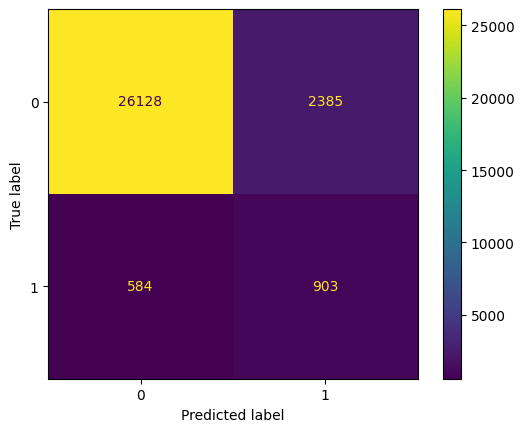

In [35]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = RandomForestClassifier(
    n_estimators=500,
    class_weight="balanced_subsample",
    max_depth=10,
    random_state=42,
    n_jobs=-1,
    max_features=0.5,
    min_samples_leaf=5,
)

random_forest_pipeline = get_pipeline(random_forest_model)

random_forest_results = fit_model(
    pipeline=random_forest_pipeline, model_name="RandomForest"
)

#### XGBClassifier


XGBoost
Threshold: 0.749  |  Profit: 228680

           Train  Test  Diferencia
AUC-ROC     0.95  0.89        0.07
AUC-PR      0.60  0.46        0.14
Precision   0.47  0.37        0.10
Recall      0.67  0.52        0.15
F1-Score    0.55  0.43        0.12

Fraudes detectados:  776 de 1487 (52.2%)
No detectados:       711 (47.8%) Falsos negativos, mayor costo
Falsas alarmas:      1310 (4.6%) Falsos positivos


              precision    recall  f1-score   support

    Legítima       0.97      0.95      0.96     28513
      Fraude       0.37      0.52      0.43      1487

    accuracy                           0.93     30000
   macro avg       0.67      0.74      0.70     30000
weighted avg       0.94      0.93      0.94     30000



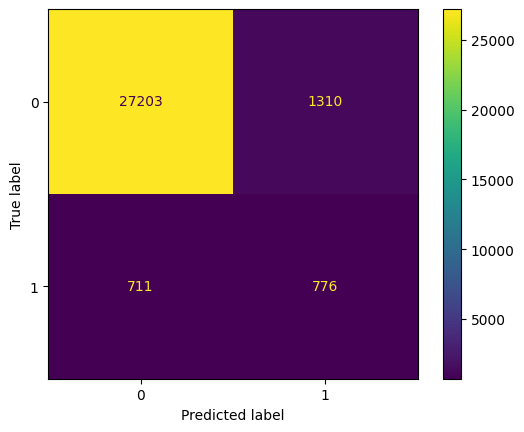

In [36]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    scale_pos_weight=len(y_train[y_train == 0]) / len(y_train[y_train == 1]),
    random_state=42,
    max_depth=6,
    learning_rate=0.05,
    n_estimators=300,
    subsample=0.8,
    colsample_bytree=0.8,
)

xgb_pipeline = get_pipeline(xgb_model)


xgb_results = fit_model(pipeline=xgb_pipeline, model_name="XGBoost")

#### LightGBM

c:\Users\Candela\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Candela\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



LightGBM
Threshold: 0.739  |  Profit: 229500

           Train  Test  Diferencia
AUC-ROC     0.93  0.89        0.04
AUC-PR      0.54  0.46        0.08
Precision   0.40  0.34        0.06
Recall      0.65  0.56        0.09
F1-Score    0.50  0.43        0.07

Fraudes detectados:  835 de 1487 (56.2%)
No detectados:       652 (43.8%) Falsos negativos, mayor costo
Falsas alarmas:      1592 (5.6%) Falsos positivos


              precision    recall  f1-score   support

    Legítima       0.98      0.94      0.96     28513
      Fraude       0.34      0.56      0.43      1487

    accuracy                           0.93     30000
   macro avg       0.66      0.75      0.69     30000
weighted avg       0.95      0.93      0.93     30000



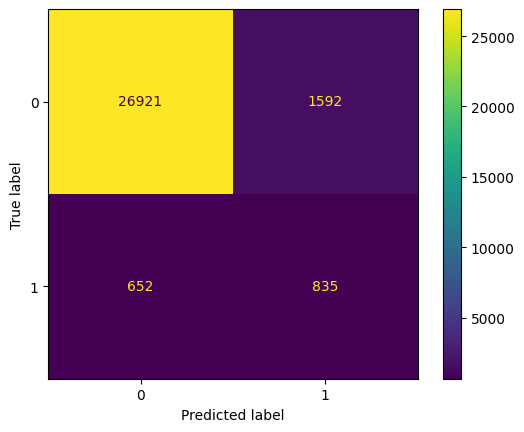

In [37]:
from lightgbm import LGBMClassifier

lgbm_model = LGBMClassifier(
    scale_pos_weight=len(y_train[y_train == 0]) / len(y_train[y_train == 1]),
    n_estimators=300,
    max_depth=5,
    num_leaves=32,
    learning_rate=0.06,
    subsample=0.75,
    colsample_bytree=0.75,
    min_child_samples=30,
    reg_alpha=1.0,
    reg_lambda=2.0,
    random_state=42,
    n_jobs=-1,
    verbose=-1,
)


lgbm_pipeline = get_pipeline(lgbm_model)

lgbm_results = fit_model(pipeline=lgbm_pipeline, model_name="LightGBM")

#### Comparación de modelos

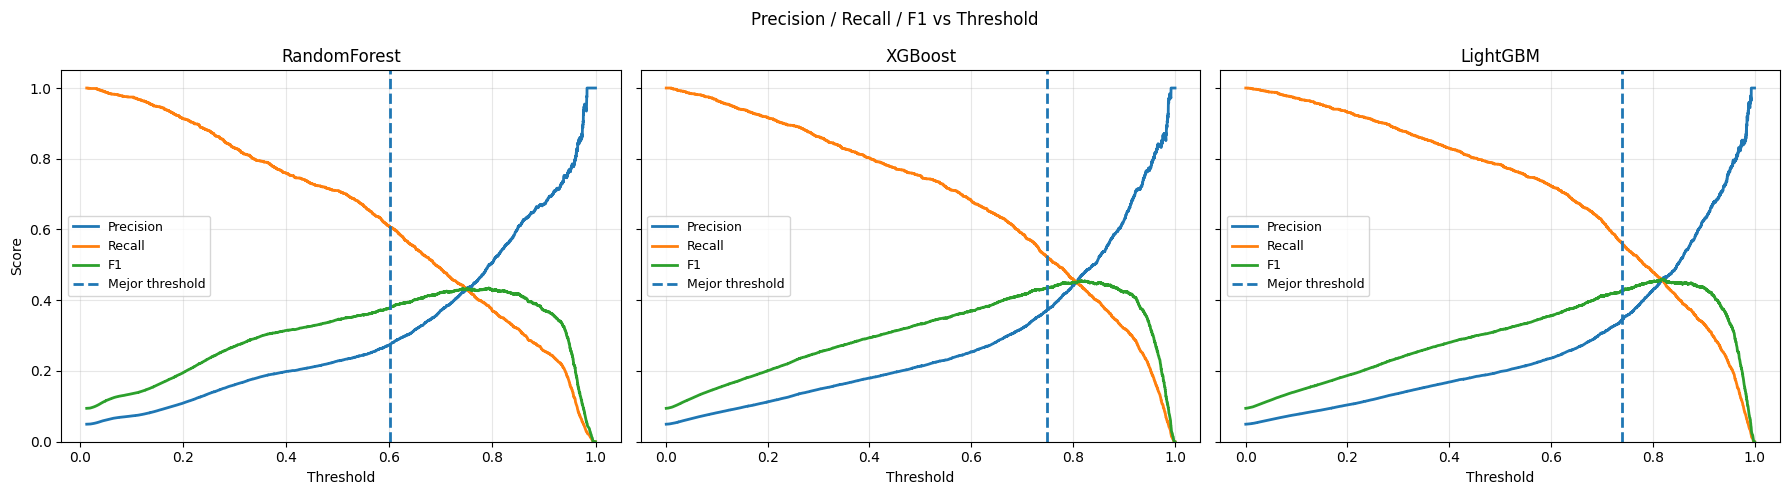

              AUC-ROC  AUC-PR  Recall  F1-Score     Profit
RandomForest     0.88    0.43    0.61      0.38  219341.34
XGBoost          0.89    0.46    0.52      0.43  228680.02
LightGBM         0.89    0.46    0.56      0.43  229500.14


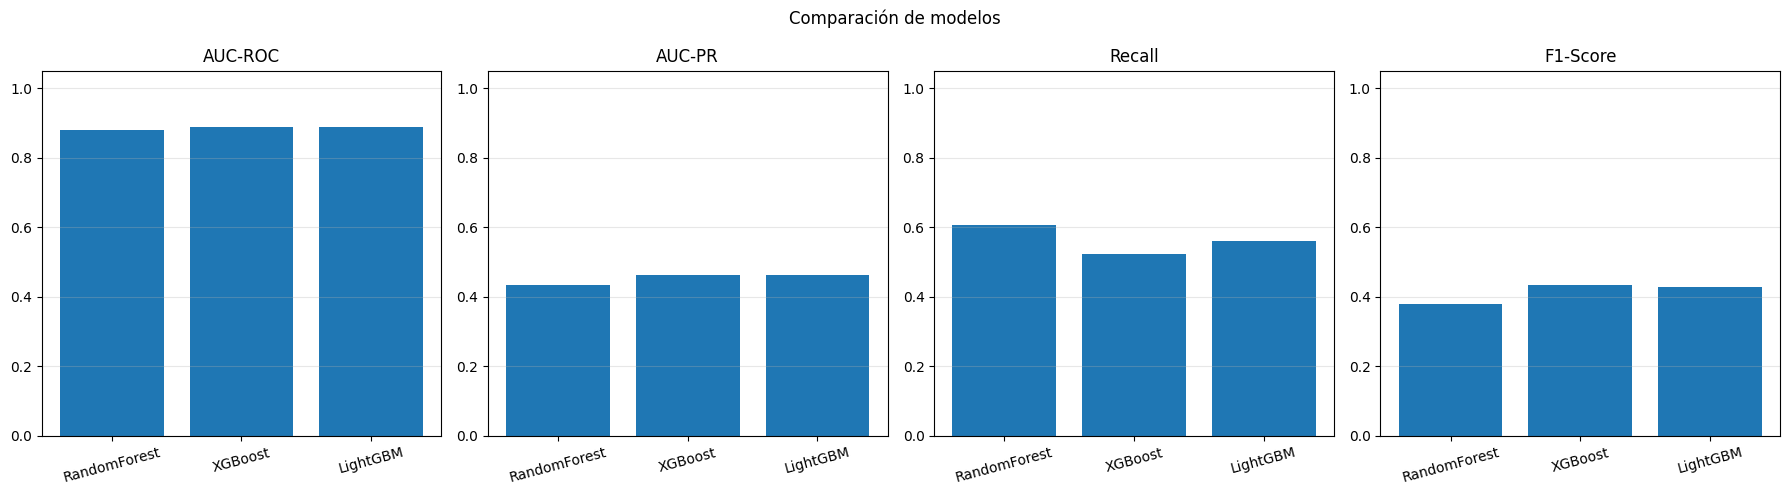

In [38]:
from sklearn.metrics import precision_recall_curve

results_list = [random_forest_results, xgb_results, lgbm_results]

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, results in zip(axes, results_list):
    proba = results["test"]["proba"]
    precision, recall, thresholds = precision_recall_curve(y_test, proba)
    thresholds = np.append(thresholds, 1)
    f1 = 2 * (precision * recall) / (precision + recall + 1e-8)

    ax.plot(thresholds, precision, lw=2, label="Precision")
    ax.plot(thresholds, recall, lw=2, label="Recall")
    ax.plot(thresholds, f1, lw=2, label="F1")
    ax.axvline(results["best_threshold"], linestyle="--", lw=2, label="Mejor threshold")
    ax.set_title(results["model_name"], fontsize=12)
    ax.set_xlabel("Threshold")
    ax.set_ylim(0, 1.05)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=9)

axes[0].set_ylabel("Score")
plt.suptitle("Precision / Recall / F1 vs Threshold")
plt.tight_layout()
plt.show()

model_names = [r["model_name"] for r in results_list]
aucs = [r["test"]["auc"] for r in results_list]
aps = [r["test"]["average_precision"] for r in results_list]
recalls = [r["test"]["recall"] for r in results_list]
f1_scores = [r["test"]["f1_score"] for r in results_list]
profits = [r["best_profit"] for r in results_list]

comparison = pd.DataFrame(
    {
        "AUC-ROC": aucs,
        "AUC-PR": aps,
        "Recall": recalls,
        "F1-Score": f1_scores,
        "Profit": profits,
    },
    index=model_names,
)

print(comparison.round(2))

fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for ax, col in zip(axes, ["AUC-ROC", "AUC-PR", "Recall", "F1-Score"]):
    ax.bar(model_names, comparison[col])
    ax.set_title(col, fontsize=12)
    ax.set_ylim(0, 1.05)
    ax.grid(alpha=0.3, axis="y")
    ax.tick_params(axis="x", rotation=15)

plt.suptitle("Comparación de modelos")
plt.tight_layout()
plt.show()

En los gráficos anteriores se puede observar las curvas de Precision, Recall y F1-Score con sus umbrales de decisión óptimos que maximizan la ganancia con el subdataset de test. Por otro lado se tienen otras métricas características de la detección (AUC-PR y AUC-ROC) que fueron plasmadas en los últimas gráficos y tablas

#### Validacíón de la ganancia

In [39]:
profit_maximo = X_test[y_test == 0]["monto"].sum() * 0.25
print(f"Profit máximo teórico (0 fraudes aprobados): ${profit_maximo:.2f}")

fraude_total = X_test[y_test == 1]["monto"].sum()
legit_total = X_test[y_test == 0]["monto"].sum()
profit_sin_modelo = legit_total * 0.25 - fraude_total * 1.0
print(f"Profit sin modelo (aprobando todo): ${profit_sin_modelo:.2f}")

Profit máximo teórico (0 fraudes aprobados): $297624.55
Profit sin modelo (aprobando todo): $186393.99


Tienen sentidos los valores de ganancia

### Conclusiones

El mejor modelo en términos de ganancia terminó siendo LightLGBM. Sin embargo, XGBoost tampoco presentó demasiadas diferencias en sus métricas, solo que menor ganancia.

Todos los modelos presentaron un AUC-PR cercano al 50% en test. Esto generalmente no es bueno, pero se considera que al estar tan desbalanceado el dataset, es una métrica aceptable. Esto no implica que no se pueda seguir mejorando.